# One-at-a-Time (OAT) Manning’s n Sensitivity Analysis

This notebook performs a **one-at-a-time (OAT)** sensitivity analysis on Manning’s n values
using a 2D HEC-RAS model. Each land cover class is varied individually while holding all
others at their baseline values, producing sensitivity curves and a tornado diagram.

**Key Concepts:**
- OAT sensitivity: vary one parameter at a time to isolate its effect
- Manning’s n range tables with configurable interval stepping
- Parallel plan execution with `RasCmdr.compute_parallel()`
- Sensitivity curves and tornado diagram visualization

**Prerequisites:** HEC-RAS 6.x+ installed, ras-commander package

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ras_commander import (
        init_ras_project, RasCmdr, RasPlan, RasGeo, RasExamples,
        RasMap, RasMonteCarlo
    )
    from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan
except ImportError:
    current_file = Path("__file__").resolve()
    parent_directory = current_file.parent.parent
    sys.path.append(str(parent_directory))
    from ras_commander import (
        init_ras_project, RasCmdr, RasPlan, RasGeo, RasExamples,
        RasMap, RasMonteCarlo
    )
    from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan

## Configuration

All parameters for the analysis are defined here. Adjust `INTERVAL` to control
the granularity of the sensitivity sweep (smaller interval = more plans = longer runtime).

In [2]:
# === PROJECT CONFIGURATION ===
PROJECT_NAME = os.getenv("RAS_COMMANDER_711_PROJECT_NAME", "Muncie")  # RasExamples project name
PROJECT_PATH_OVERRIDE = os.getenv("RAS_COMMANDER_711_PROJECT_PATH")    # Optional external RAS project folder
RAS_VERSION = os.getenv("RAS_COMMANDER_711_RAS_VERSION", "6.6")        # HEC-RAS version string
TEMPLATE_PLAN = os.getenv("RAS_COMMANDER_711_TEMPLATE_PLAN", "04")    # Plan number with 2D geometry

# === SENSITIVITY CONFIGURATION ===
INTERVAL = float(os.getenv("RAS_COMMANDER_711_INTERVAL", "0.02"))      # Manning's n step size for sweep

# === POINT OF INTEREST ===
# Defaults are for the Muncie example project (State Plane Indiana East, ft).
# For external projects, override with RAS_COMMANDER_711_POI_X/Y/LABEL.
POI_X = float(os.getenv("RAS_COMMANDER_711_POI_X", "408350.0"))
POI_Y = float(os.getenv("RAS_COMMANDER_711_POI_Y", "1802550.0"))
POI_LABEL = os.getenv("RAS_COMMANDER_711_POI_LABEL", "Mid-Floodplain POI")

# === EXECUTION ===
MAX_WORKERS = int(os.getenv("RAS_COMMANDER_711_MAX_WORKERS", "4"))     # Local parallel workers
NUM_CORES = int(os.getenv("RAS_COMMANDER_711_NUM_CORES", "2"))         # CPU cores per HEC-RAS instance

# === RASREMOTE EXECUTION ===
def _env_bool(name, default):
    value = os.getenv(name)
    if value is None:
        return default
    return value.strip().lower() in {"1", "true", "yes", "y", "on"}

USE_REMOTE_WORKERS = _env_bool("RAS_COMMANDER_711_USE_REMOTE", True)
REQUESTED_REMOTE_WORKERS = tuple(
    label.strip()
    for label in os.getenv("RAS_COMMANDER_711_REMOTE_WORKERS", "CLB02,CLB04,CLB06,CLB10").split(",")
    if label.strip()
)
CLEAR_GEOMPRE = _env_bool("RAS_COMMANDER_711_CLEAR_GEOMPRE", True)  # Regenerate geometry preprocessor files after Manning's n edits


## Configure RasRemote Workers

Load the CLB RasRemote fleet from the gitignored worker configuration. Passwords are never printed.


In [3]:
import json

# RasRemote Worker Setup
# Loads a worker fleet from working/remote_workers_clb.json (gitignored, has real credentials).
# Falls back to examples/remote_workers_clb_template.json (committed, redacted) for reference.
# Requested labels are filtered so this notebook cannot spill onto older CLB workers.
_cwd = Path.cwd()
if (_cwd / "remote_workers_clb_template.json").exists():
    _repo_root = _cwd.parent
    _examples_dir = _cwd
else:
    _repo_root = _cwd
    _examples_dir = _cwd / "examples"

_workers_json_real = _repo_root / "working" / "remote_workers_clb.json"
_workers_json_template = _examples_dir / "remote_workers_clb_template.json"
_requested_labels = {label.upper() for label in REQUESTED_REMOTE_WORKERS}

def _worker_label_from_name(name: str):
    normalized = name.upper().replace("CLB-", "CLB")
    for label in sorted(_requested_labels):
        if label in normalized:
            return label
    return None

remote_workers = []
remote_worker_status = pd.DataFrame()

if USE_REMOTE_WORKERS:
    try:
        from ras_commander.remote import load_workers_from_json

        _cfg_path = _workers_json_real if _workers_json_real.exists() else _workers_json_template
        _cfg_raw = json.loads(_cfg_path.read_text())

        _status_rows = []
        _enabled_requested_labels = set()
        for _entry in _cfg_raw.get("workers", []):
            _label = _worker_label_from_name(_entry.get("name", ""))
            if _label is None:
                continue
            if _entry.get("enabled", False):
                _enabled_requested_labels.add(_label)
            _status_rows.append({
                "label": _label,
                "name": _entry.get("name", ""),
                "enabled": bool(_entry.get("enabled", False)),
                "hostname": _entry.get("hostname", ""),
                "share_path": _entry.get("share_path", ""),
                "session_id": _entry.get("session_id", ""),
                "slots": (_entry.get("cores_total", 0) or 0) // max((_entry.get("cores_per_plan", 1) or 1), 1),
                "note": _entry.get("_note", ""),
            })

        _loaded_workers = load_workers_from_json(_cfg_path, enabled_only=True)
        remote_workers = [
            _worker for _worker in _loaded_workers
            if getattr(_worker, "worker_type", "") != "local"
            and _worker_label_from_name(getattr(_worker, "worker_id", "")) in _requested_labels
        ]

        _loaded_labels = {
            _worker_label_from_name(getattr(_worker, "worker_id", ""))
            for _worker in remote_workers
        }
        _loaded_labels.discard(None)
        _missing_labels = sorted(_requested_labels - _loaded_labels)
        _total_slots = sum(getattr(_worker, "max_parallel_plans", 1) or 1 for _worker in remote_workers)

        remote_worker_status = pd.DataFrame(_status_rows).sort_values(["label", "name"])
        print(remote_worker_status.to_string(index=False))
        print(f"Loaded {len(remote_workers)} RasRemote workers ({_total_slots} concurrent slots).")
        if _missing_labels:
            print(f"Requested worker labels not loaded: {', '.join(_missing_labels)}")
    except Exception as _e:
        print(f"Warning: could not load RasRemote workers ({_e}) -- falling back to local execution.")
        USE_REMOTE_WORKERS = False
        remote_workers = []
else:
    print("USE_REMOTE_WORKERS = False -- using local compute_parallel.")
    print(f"Worker config available at: {_workers_json_real}")


USE_REMOTE_WORKERS = False -- using local compute_parallel.
Worker config available at: G:\GH\ras-commander\working\remote_workers_clb.json


## Extract Example Project and Initialize

In [4]:
if PROJECT_PATH_OVERRIDE:
    project_folder = Path(PROJECT_PATH_OVERRIDE).expanduser()
    project_source = "external override"
else:
    project_folder = RasExamples.extract_project(PROJECT_NAME)
    project_source = "RasExamples"

ras = init_ras_project(project_folder, RAS_VERSION)

print(f"Project: {project_folder}")
print(f"Source: {project_source}")
print(f"RAS version: {RAS_VERSION}")
print(f"Plans: {len(ras.plan_df)}")
print(f"Template plan: {TEMPLATE_PLAN}")
print()
print("Plan DataFrame:")
ras.plan_df[["plan_number", "Plan Title", "Geom File"]].head(10)


2026-06-23 19:55:58 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-06-23 19:55:58 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-06-23 19:55:58 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-06-23 19:55:58 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-06-23 19:55:58 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-06-23 19:55:59 - ras_commander.RasPrj - INFO - Project initialized: sabuto | Folder: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529


2026-06-23 19:55:59 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-06-23 19:55:59 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Project: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529
Source: external override
RAS version: 6.6
Plans: 1
Template plan: 93

Plan DataFrame:


,plan_number,Plan Title,Geom File
0,93,plan_2169 cms_76600 cfs,05


## Read Baseline Manning’s n Values

Extract the current Manning’s n values from the template geometry file.
These serve as the baseline for the OAT sensitivity analysis.

In [5]:
# Get geometry file path from template plan
template_row = ras.plan_df[ras.plan_df["plan_number"] == TEMPLATE_PLAN].iloc[0]
template_geom_number = str(template_row["geometry_number"]).zfill(2)
geom_file = Path(template_row["Geom Path"])
if not geom_file.exists():
    geom_file = project_folder / f"{ras.project_name}.g{template_row['geometry_number']}"

# Read base overrides (primary Manning's n table)
base_overrides_df = RasGeo.get_mannings_baseoverrides(geom_file).copy()
base_overrides_df["Base Mannings n Value"] = pd.to_numeric(
    base_overrides_df["Base Mannings n Value"], errors="coerce"
)
base_overrides = dict(zip(
    base_overrides_df["Land Cover Name"],
    base_overrides_df["Base Mannings n Value"],
))

print("Base Manning's n Overrides:")
print(f"  Land covers: {len(base_overrides)}")
for name, n_val in base_overrides.items():
    print(f"  {name}: n = {n_val}")

# Read regional overrides
regional_overrides_df = RasGeo.get_mannings_regionoverrides(geom_file)
print()
print(f"Regional Overrides: {len(regional_overrides_df)} rows")
if not regional_overrides_df.empty:
    print(regional_overrides_df.to_string(index=False))


Base Manning's n Overrides:
  Land covers: 13
  1: n = 0.04
  10: n = 0.03
  11: n = 0.035
  12: n = 0.12
  13: n = 0.07
  2: n = 0.1
  3: n = 0.08
  4: n = 0.04
  5: n = 0.15
  6: n = 0.16
  7: n = 0.16
  8: n = 0.1
  9: n = 0.035

Regional Overrides: 0 rows


## Build Manning’s n Range Table

Define min/max bounds for each land cover class. Obstruction values (n >= 1.0,
typically buildings at n=100) are excluded from the sensitivity analysis since
they represent physical barriers, not roughness.

In [6]:
# Standard Manning's n ranges by land cover type
# Source: HEC-RAS Reference Manual, Chow (1959)
MANNINGS_RANGES = {
    "Pasture":           (0.025, 0.050),
    "Brush":             (0.040, 0.120),
    "Trees":             (0.060, 0.200),
    "Low Intensity":     (0.040, 0.120),
    "High Intensity":    (0.060, 0.200),
    "Water":             (0.025, 0.050),
    "Cropland":          (0.020, 0.060),
    "Wetland":           (0.030, 0.100),
    "Barren":            (0.010, 0.035),
}

OBSTRUCTION_THRESHOLD = 1.0  # n values >= this are obstructions

# Build range table from base overrides
range_table = {}
excluded = {}

for name, baseline_n in base_overrides.items():
    if baseline_n >= OBSTRUCTION_THRESHOLD:
        excluded[name] = baseline_n
        continue
    
    if name in MANNINGS_RANGES:
        n_min, n_max = MANNINGS_RANGES[name]
    else:
        # Default: +/- 50% of baseline, clamped to [0.01, 0.5]
        n_min = max(0.01, baseline_n * 0.5)
        n_max = min(0.50, baseline_n * 1.5)
    
    range_table[name] = {
        "baseline": baseline_n,
        "min": n_min,
        "max": n_max,
        "steps": np.arange(n_min, n_max + INTERVAL / 2, INTERVAL)
    }

print("=== Sensitivity Range Table ===")
print(f"Variable land covers: {len(range_table)}")
print(f"Excluded (obstructions): {len(excluded)}")
print()

total_plans = sum(len(v["steps"]) for v in range_table.values())
print(f"Total plans to create: {total_plans}")
print()

for name, info in range_table.items():
    print(f'  {name}: baseline={info["baseline"]:.3f}, '
          f'range=[{info["min"]:.3f}, {info["max"]:.3f}], '
          f'steps={len(info["steps"])}')

if excluded:
    print(f"\nExcluded obstructions:")
    for name, n_val in excluded.items():
        print(f"  {name}: n = {n_val} (held constant)")

=== Sensitivity Range Table ===
Variable land covers: 13
Excluded (obstructions): 0

Total plans to create: 68

  1: baseline=0.040, range=[0.020, 0.060], steps=3
  10: baseline=0.030, range=[0.015, 0.045], steps=2
  11: baseline=0.035, range=[0.018, 0.053], steps=3
  12: baseline=0.120, range=[0.060, 0.180], steps=7
  13: baseline=0.070, range=[0.035, 0.105], steps=4
  2: baseline=0.100, range=[0.050, 0.150], steps=6
  3: baseline=0.080, range=[0.040, 0.120], steps=5
  4: baseline=0.040, range=[0.020, 0.060], steps=3
  5: baseline=0.150, range=[0.075, 0.225], steps=8
  6: baseline=0.160, range=[0.080, 0.240], steps=9
  7: baseline=0.160, range=[0.080, 0.240], steps=9
  8: baseline=0.100, range=[0.050, 0.150], steps=6
  9: baseline=0.035, range=[0.018, 0.053], steps=3


## Create OAT Sensitivity Plans

For each land cover, create a set of plans that vary only that land cover's
Manning's n while keeping all others at baseline. Each plan gets a cloned
geometry file, and the cloned plan is modified through
`RasMonteCarlo.make_mannings_apply_fn(path="plaintext")`, which edits the
plain-text `LCMann Table` in that clone's `.g##`. Execution must use
`clear_geompre=True` so HEC-RAS regenerates cached per-cell Manning's n.


In [7]:
plan_registry = []  # Track all created plans
plan_counter = 0

# Canonical 2D land-cover roughness propagation path:
#   cloned .g## per plan + plaintext LCMann Table edit + clear_geompre=True at execution.
# This mirrors RasMonteCarlo.run_ensemble(..., clone_geom=True, clear_geompre=True)
# without building a stochastic ensemble.
mannings_apply_fn = RasMonteCarlo.make_mannings_apply_fn(
    zone_column_map={str(name): str(name) for name in base_overrides_df["Land Cover Name"]},
    path="plaintext",
)

for lc_name, info in range_table.items():
    print(f"\nCreating plans for: {lc_name} ({len(info['steps'])} steps)")
    
    for n_value in info["steps"]:
        plan_counter += 1
        plan_title = f"OAT_{str(lc_name)[:8]}_{n_value:.3f}"
        
        # Clone plan and geometry from template. Each sensitivity plan needs its own
        # geometry so its plaintext LCMann Table does not collide with other runs.
        new_plan_number = RasPlan.clone_plan(TEMPLATE_PLAN, ras_object=ras)
        new_geom_number = RasPlan.clone_geom(template_geom_number, ras_object=ras)
        
        # Link cloned plan to cloned geometry
        RasPlan.set_geom(new_plan_number, new_geom_number, ras_object=ras)
        
        # Set plan title
        plan_file = ras.project_folder / f"{ras.project_name}.p{new_plan_number}"
        RasPlan.set_plan_title(plan_file, plan_title)
        
        # Modify Manning's n through the hardened plaintext LCMann propagation path:
        # build a full row of baseline class n values, then perturb only the target class.
        sample_row = pd.Series({str(k): float(v) for k, v in base_overrides.items()})
        sample_row[str(lc_name)] = float(n_value)
        mannings_apply_fn(plan_file, sample_row, ras_object=ras)
        
        plan_registry.append({
            "land_cover": lc_name,
            "n_value": round(float(n_value), 4),
            "plan_number": new_plan_number,
            "geom_number": new_geom_number,
            "Plan Title": plan_title,
            "is_baseline": abs(float(n_value) - float(info["baseline"])) < 1e-6,
        })

# Refresh project state
ras = init_ras_project(project_folder, RAS_VERSION)

registry_df = pd.DataFrame(plan_registry)
print("\n=== Plan Registry ===")
print(f"Total plans created: {len(registry_df)}")
print(f"Land covers varied: {registry_df['land_cover'].nunique()}")
print("\nPlans per land cover:")
print(registry_df.groupby("land_cover").size())


2026-06-23 19:55:59 - ras_commander.RasUtils - INFO - File cloned from H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\sabuto.p93 to H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\sabuto.p01


2026-06-23 19:55:59 - ras_commander.RasUtils - INFO - Successfully updated file: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\sabuto.p01


2026-06-23 19:55:59 - ras_commander.RasUtils - INFO - Project file updated with new Plan entry: 01



Creating plans for: 1 (3 steps)


2026-06-23 19:55:59 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\sabuto.rasmap


...

2026-06-23 20:03:10 - ras_commander.RasPrj - INFO - ras-commander v0.97.1 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-23 20:03:10 - ras_commander.RasPrj - INFO - Project initialized: sabuto | Folder: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529


2026-06-23 20:03:10 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-06-23 20:03:10 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_


=== Plan Registry ===
Total plans created: 68
Land covers varied: 13

Plans per land cover:
land_cover
1     3
10    2
11    3
12    7
13    4
2     6
3     5
4     3
5     8
6     9
7     9
8     6
9     3
dtype: int64


## Execute All Plans

Run the sensitivity plans with RasRemote when configured, otherwise use local parallel execution.


In [8]:
all_plan_numbers = registry_df["plan_number"].tolist()

if USE_REMOTE_WORKERS and remote_workers:
    from ras_commander.remote import compute_parallel_remote

    total_slots = sum(getattr(worker, "max_parallel_plans", 1) or 1 for worker in remote_workers)
    print(
        f"Executing {len(all_plan_numbers)} plans with RasRemote "
        f"on {len(remote_workers)} workers ({total_slots} slots)..."
    )

    remote_results = compute_parallel_remote(
        plan_numbers=all_plan_numbers,
        workers=remote_workers,
        ras_object=ras,
        num_cores=NUM_CORES,
        clear_geompre=CLEAR_GEOMPRE,
        force_rerun=True,
    )

    execution_summary = pd.DataFrame([
        {
            "plan_number": plan_num,
            "worker_id": result.worker_id,
            "success": result.success,
            "execution_time_sec": round(result.execution_time, 1),
            "hdf_path": result.hdf_path or "",
            "error_message": result.error_message or "",
        }
        for plan_num, result in sorted(remote_results.items())
    ])
    print(execution_summary.to_string(index=False))

    failed = execution_summary[~execution_summary["success"]]
    if not failed.empty:
        raise RuntimeError(f"{len(failed)} RasRemote plan(s) failed; see execution_summary above.")
else:
    print(f"Executing {len(all_plan_numbers)} plans locally with {MAX_WORKERS} workers...")
    local_result = RasCmdr.compute_parallel(
        plan_number=all_plan_numbers,
        max_workers=MAX_WORKERS,
        num_cores=NUM_CORES,
        clear_geompre=CLEAR_GEOMPRE,
        force_rerun=True,
        ras_object=ras,
    )
    execution_summary = local_result.results_df.copy()

# Refresh after execution
ras = init_ras_project(project_folder, RAS_VERSION)
print("Execution complete.")


2026-06-23 20:03:10 - ras_commander.RasCmdr - INFO - Filtered plans to execute: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68']


2026-06-23 20:03:10 - ras_commander.RasCmdr - INFO - Adjusted max_workers to 4 based on the number of plans to compute: 68


Executing 68 plans locally with 4 workers...


2026-06-23 20:03:11 - ras_commander.RasCmdr - INFO - Created worker folder: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529 [Worker 1]


2026-06-23 20:03:15 - ras_commander.RasMap - INFO - Successfully parsed RASMapper file: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529 [Worker 1]\sabuto.rasmap


...

2026-06-23 22:36:08 - ras_commander.RasPrj - INFO - ras-commander v0.97.1 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-06-23 22:36:08 - ras_commander.RasPrj - INFO - Project initialized: sabuto | Folder: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529


2026-06-23 22:36:08 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-06-23 22:36:08 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://gpt-cmdr.github.io/ras-commander/
Repo: https://github.com/gpt-cmdr/ras-commander
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode()
  Plan Files:   RasPlan.clone_

Execution complete.


## Verify Roughness Propagation

Before interpreting WSE differences, verify that at least one OAT roughness change reached the
preprocessed 2D geometry. This checks the cached `Cells Center Manning's n` dataset in the
cloned geometry HDFs. If this fails, the runs are hydraulically inert regardless of HEC-RAS
completion status. Converted legacy projects may still fail here if the land-cover association
cannot be sampled into 2D cells.


In [9]:
import h5py


def _cell_mannings_n_from_geom_hdf(geom_hdf_path):
    geom_hdf_path = Path(geom_hdf_path)
    if not geom_hdf_path.exists():
        return None
    with h5py.File(geom_hdf_path, "r") as hdf_file:
        areas = hdf_file.get("Geometry/2D Flow Areas", {})
        for area_name in areas.keys():
            ds_path = f"Geometry/2D Flow Areas/{area_name}/Cells Center Manning's n"
            if ds_path in hdf_file:
                return np.asarray(hdf_file[ds_path][...], dtype=float)
    return None


propagation_rows = []
for lc_name, group in registry_df.groupby("land_cover"):
    if len(group) < 2:
        continue
    low_row = group.sort_values("n_value").iloc[0]
    high_row = group.sort_values("n_value").iloc[-1]
    low_hdf = project_folder / f"{ras.project_name}.g{str(low_row['geom_number']).zfill(2)}.hdf"
    high_hdf = project_folder / f"{ras.project_name}.g{str(high_row['geom_number']).zfill(2)}.hdf"
    low_n = _cell_mannings_n_from_geom_hdf(low_hdf)
    high_n = _cell_mannings_n_from_geom_hdf(high_hdf)
    if low_n is None or high_n is None:
        propagation_rows.append({
            "land_cover": lc_name,
            "low_geom": low_hdf.name,
            "high_geom": high_hdf.name,
            "status": "missing_cell_mannings_n",
            "max_delta_n": np.nan,
        })
        continue
    if low_n.shape != high_n.shape:
        propagation_rows.append({
            "land_cover": lc_name,
            "low_geom": low_hdf.name,
            "high_geom": high_hdf.name,
            "status": "shape_mismatch",
            "max_delta_n": np.nan,
        })
        continue
    delta = np.abs(high_n - low_n)
    propagation_rows.append({
        "land_cover": lc_name,
        "low_geom": low_hdf.name,
        "high_geom": high_hdf.name,
        "low_n": float(low_row["n_value"]),
        "high_n": float(high_row["n_value"]),
        "status": "ok",
        "max_delta_n": float(np.nanmax(delta)),
        "changed_cells": int(np.count_nonzero(delta > 1e-8)),
    })

propagation_df = pd.DataFrame(propagation_rows)
display(propagation_df.sort_values("max_delta_n", ascending=False, na_position="last"))

valid_delta = propagation_df.loc[propagation_df["status"] == "ok", "max_delta_n"].dropna()
if valid_delta.empty or float(valid_delta.max()) <= 1e-8:
    raise RuntimeError(
        "Manning's n perturbations did not reach preprocessed cell n. "
        "Verify cloned geometries, plaintext LCMann edits, and clear_geompre=True."
    )

print(f"Roughness propagation confirmed: max |delta n| = {float(valid_delta.max()):.6g}")


,land_cover,low_geom,high_geom,low_n,high_n,status,max_delta_n,changed_cells
10,7,sabuto.g52.hdf,sabuto.g60.hdf,0.0800,0.2400,ok,0.160000,2371
9,6,sabuto.g43.hdf,sabuto.g51.hdf,0.0800,0.2400,ok,0.159989,1202
8,5,sabuto.g35.hdf,sabuto.g42.hdf,0.0750,0.2150,ok,0.139986,48
3,12,sabuto.g10.hdf,sabuto.g16.hdf,0.0600,0.1800,ok,0.120022,1621
11,8,sabuto.g61.hdf,sabuto.g66.hdf,0.0500,0.1500,ok,0.100019,20321
5,2,sabuto.g21.hdf,sabuto.g26.hdf,0.0500,0.1500,ok,0.100000,1980
6,3,sabuto.g27.hdf,sabuto.g31.hdf,0.0400,0.1200,ok,0.080000,359
4,13,sabuto.g17.hdf,sabuto.g20.hdf,0.0350,0.0950,ok,0.055452,1748
2,11,sabuto.g07.hdf,sabuto.g09.hdf,0.0175,0.0575,ok,0.040000,1731
12,9,sabuto.g67.hdf,sabuto.g69.hdf,0.0175,0.0575,ok,0.040000,3248


Roughness propagation confirmed: max |delta n| = 0.16


## Extract Results at Point of Interest

For each executed plan, extract the maximum water surface elevation (WSE)
at the point of interest. This allows us to measure the sensitivity of WSE
to each land cover’s Manning’s n value.

In [10]:
from scipy.spatial import cKDTree

results = []

for _, row in registry_df.iterrows():
    plan_num = row["plan_number"]

    try:
        # Get HDF path from plan_df
        plan_row = ras.plan_df[ras.plan_df["plan_number"] == plan_num]
        if plan_row.empty:
            print(f"  Plan {plan_num}: not found in plan_df")
            continue

        hdf_path = plan_row["HDF_Results_Path"].iloc[0]
        if pd.isna(hdf_path) or not Path(hdf_path).exists():
            print(f"  Plan {plan_num}: no HDF results")
            continue

        hdf_path = Path(hdf_path)

        # Use the summary output: maximum water surface per mesh cell.
        max_ws = HdfResultsMesh.get_mesh_max_ws(hdf_path)
        if max_ws.empty:
            print(f"  Plan {plan_num}: maximum WSE summary is empty")
            continue

        coords = np.column_stack([max_ws.geometry.x, max_ws.geometry.y])
        tree = cKDTree(coords)
        dist, idx = tree.query([POI_X, POI_Y])
        nearest = max_ws.iloc[idx]
        max_wse = nearest["maximum_water_surface"]

        results.append({
            "land_cover": row["land_cover"],
            "n_value": row["n_value"],
            "plan_number": plan_num,
            "max_wse_ft": float(max_wse),
            "is_baseline": row["is_baseline"],
            "poi_cell_dist_ft": float(dist),
            "mesh_name": nearest.get("mesh_name", ""),
            "cell_id": int(nearest.get("cell_id", -1)),
        })

    except Exception as e:
        print(f'  Plan {plan_num} ({row["land_cover"]} n={row["n_value"]}): {e}')

results_df = pd.DataFrame(results)
print()
print(f"Results extracted: {len(results_df)} of {len(registry_df)} plans")
if results_df.empty:
    raise RuntimeError("No WSE results were extracted from completed HDF files.")
print(f"POI cell distance: {results_df['poi_cell_dist_ft'].iloc[0]:.1f} ft")
print()
print(f"WSE range: {results_df['max_wse_ft'].min():.2f} - {results_df['max_wse_ft'].max():.2f} ft")
results_df.head(10)


2026-06-23 22:36:08 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


2026-06-23 22:36:08 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


2026-06-23 22:36:09 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


2026-06-23 22:36:09 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


2026-06-23 22:36:09 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


...

  Plan 65 (8 n=0.15): Failed to get maximum water surface: Error processing summary output data: Plan Information not found in HDF file


2026-06-23 22:36:21 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data


2026-06-23 22:36:21 - ras_commander.hdf.HdfResultsMesh - INFO - Processed 22997 rows of summary output data



Results extracted: 62 of 68 plans
POI cell distance: 0.0 ft

WSE range: 468.01 - 468.01 ft


,land_cover,n_value,plan_number,max_wse_ft,is_baseline,poi_cell_dist_ft,mesh_name,cell_id
0,1,0.0200,01,468.005219,False,0.0,2D grids,6200
1,1,0.0400,02,468.005219,True,0.0,2D grids,6200
2,1,0.0600,03,468.005219,False,0.0,2D grids,6200
3,10,0.0150,04,468.005219,False,0.0,2D grids,6200
4,10,0.0350,05,468.005219,False,0.0,2D grids,6200
5,11,0.0175,06,468.005219,False,0.0,2D grids,6200
6,11,0.0375,07,468.005219,False,0.0,2D grids,6200
7,11,0.0575,08,468.005219,False,0.0,2D grids,6200
8,12,0.0600,09,468.005219,False,0.0,2D grids,6200
9,12,0.1000,11,468.005219,False,0.0,2D grids,6200


## Sensitivity Curves

Plot Manning’s n vs. Max WSE for each land cover class. Each subplot shows
how varying one land cover’s roughness (while holding others constant)
affects the water surface elevation at the POI.

C:\Users\bill\AppData\Local\Temp\ipykernel_30268\2917264892.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\bill\AppData\Local\Temp\ipykernel_30268\2917264892.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\bill\AppData\Local\Temp\ipykernel_30268\2917264892.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\bill\AppData\Local\Temp\ipykernel_30268\2917264892.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is calle

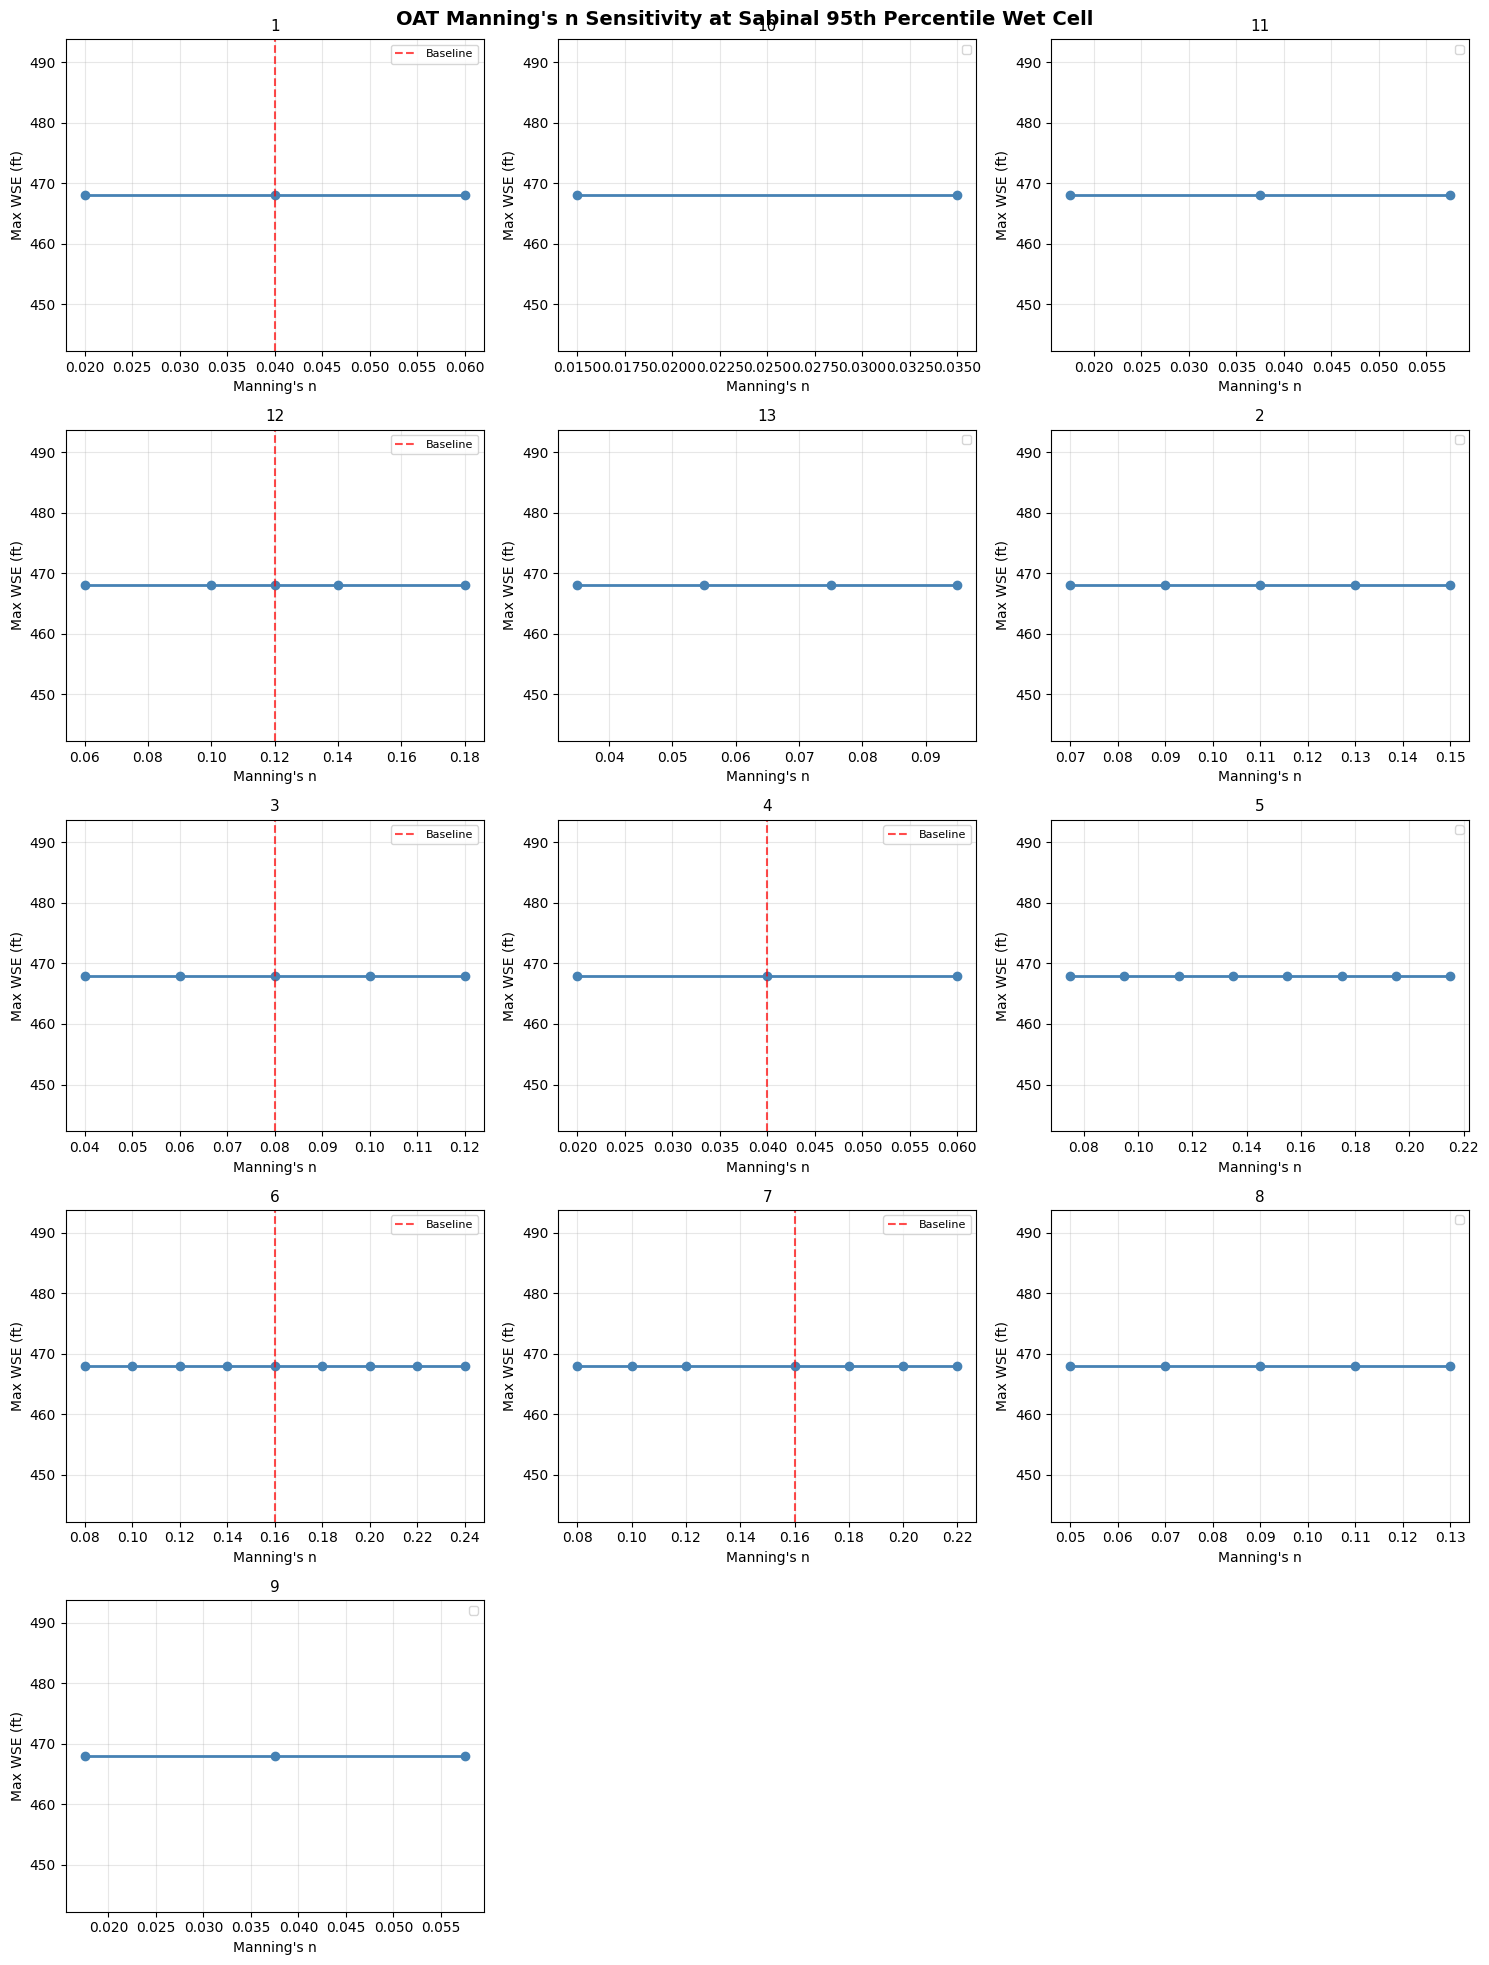

In [11]:
land_covers = results_df["land_cover"].unique()
n_lc = len(land_covers)
ncols = min(3, n_lc)
nrows = int(np.ceil(n_lc / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
fig.suptitle(f"OAT Manning's n Sensitivity at {POI_LABEL}", fontsize=14, fontweight="bold")

for i, lc_name in enumerate(land_covers):
    ax = axes[i // ncols, i % ncols]
    lc_data = results_df[results_df["land_cover"] == lc_name].sort_values("n_value")
    
    ax.plot(lc_data["n_value"], lc_data["max_wse_ft"], "o-", color="steelblue", linewidth=2)
    
    # Mark baseline
    baseline_row = lc_data[lc_data["is_baseline"]]
    if not baseline_row.empty:
        ax.axvline(baseline_row["n_value"].iloc[0], color="red", linestyle="--", alpha=0.7, label="Baseline")
    
    ax.set_title(lc_name, fontsize=11)
    ax.set_xlabel("Manning's n")
    ax.set_ylabel("Max WSE (ft)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(n_lc, nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

plt.tight_layout()
plt.show()

## Tornado Diagram

The tornado diagram ranks land cover classes by their influence on WSE.
Wider bars indicate greater sensitivity — these are the parameters that
matter most for model calibration.

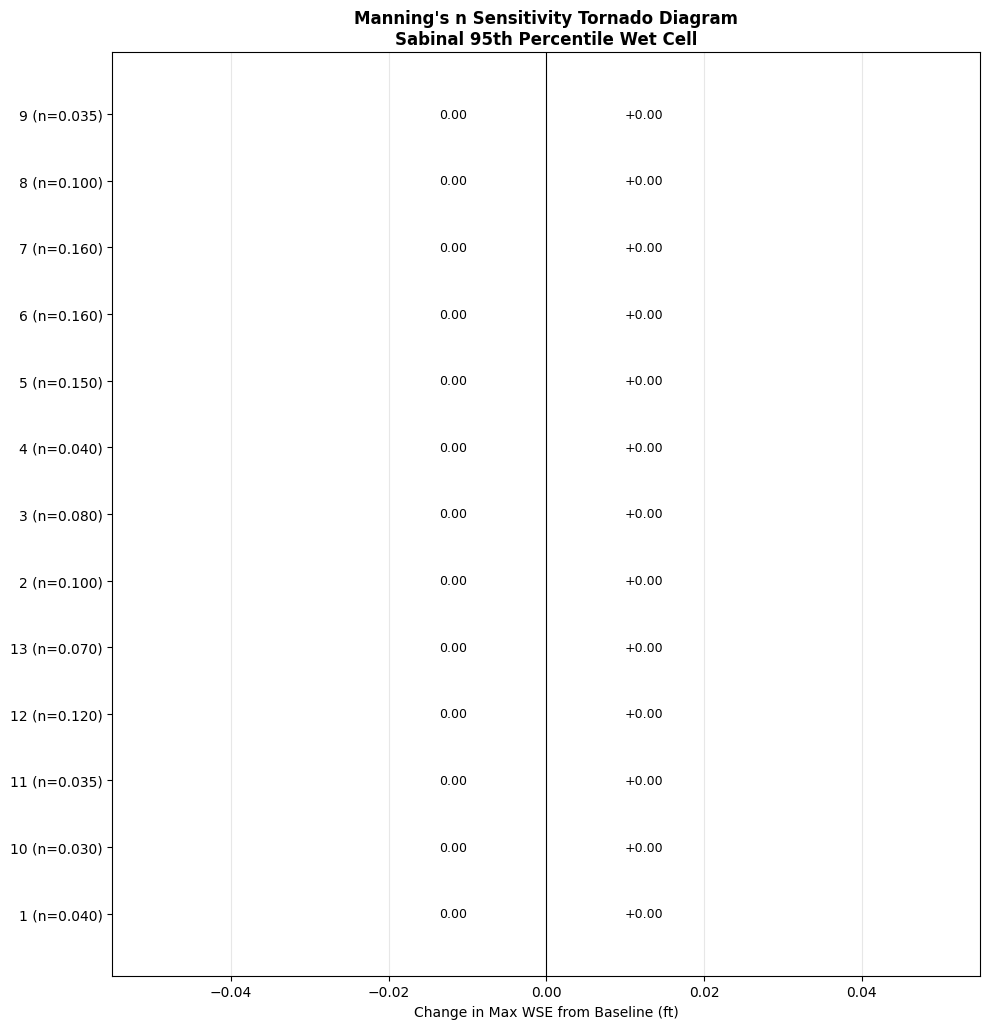


=== Sensitivity Ranking (most to least influential) ===
  9: WSE range = 0.000 ft (n: 0.018 to 0.058)
  8: WSE range = 0.000 ft (n: 0.050 to 0.130)
  7: WSE range = 0.000 ft (n: 0.080 to 0.220)
  6: WSE range = 0.000 ft (n: 0.080 to 0.240)
  5: WSE range = 0.000 ft (n: 0.075 to 0.215)
  4: WSE range = 0.000 ft (n: 0.020 to 0.060)
  3: WSE range = 0.000 ft (n: 0.040 to 0.120)
  2: WSE range = 0.000 ft (n: 0.070 to 0.150)
  13: WSE range = 0.000 ft (n: 0.035 to 0.095)
  12: WSE range = 0.000 ft (n: 0.060 to 0.180)
  11: WSE range = 0.000 ft (n: 0.018 to 0.058)
  10: WSE range = 0.000 ft (n: 0.015 to 0.035)
  1: WSE range = 0.000 ft (n: 0.020 to 0.060)


In [12]:
# Calculate WSE range (max - min) for each land cover
tornado_data = []
for lc_name in land_covers:
    lc_data = results_df[results_df["land_cover"] == lc_name]
    baseline_wse = lc_data[lc_data["is_baseline"]]["max_wse_ft"]
    baseline_val = baseline_wse.iloc[0] if not baseline_wse.empty else lc_data["max_wse_ft"].median()
    
    tornado_data.append({
        "land_cover": lc_name,
        "wse_min": lc_data["max_wse_ft"].min(),
        "wse_max": lc_data["max_wse_ft"].max(),
        "wse_range": lc_data["max_wse_ft"].max() - lc_data["max_wse_ft"].min(),
        "wse_baseline": baseline_val,
        "n_min": lc_data["n_value"].min(),
        "n_max": lc_data["n_value"].max(),
        "n_baseline": range_table[lc_name]["baseline"]
    })

tornado_df = pd.DataFrame(tornado_data).sort_values("wse_range", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(tornado_df) * 0.8)))

baseline_global = tornado_df["wse_baseline"].median()
y_pos = range(len(tornado_df))

for i, (_, row) in enumerate(tornado_df.iterrows()):
    left = row["wse_min"] - row["wse_baseline"]
    right = row["wse_max"] - row["wse_baseline"]
    
    ax.barh(i, right, left=0, height=0.6, color="steelblue", alpha=0.8)
    ax.barh(i, left, left=0, height=0.6, color="coral", alpha=0.8)
    
    ax.text(right + 0.01, i, f"+{right:.2f}", va="center", fontsize=9)
    ax.text(left - 0.01, i, f"{left:.2f}", va="center", ha="right", fontsize=9)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f'{r["land_cover"]} (n={r["n_baseline"]:.3f})' for _, r in tornado_df.iterrows()])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in Max WSE from Baseline (ft)")
ax.set_title(f"Manning's n Sensitivity Tornado Diagram\n{POI_LABEL}", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Sensitivity Ranking (most to least influential) ===")
for _, row in tornado_df.iloc[::-1].iterrows():
    print(f'  {row["land_cover"]}: WSE range = {row["wse_range"]:.3f} ft '
          f'(n: {row["n_min"]:.3f} to {row["n_max"]:.3f})')

## Export Results

Save the full results table and tornado summary as CSV files for
further analysis or reporting.

In [13]:
# Full results table
results_csv = project_folder / "oat_sensitivity_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"Full results: {results_csv}")

# Tornado summary
tornado_csv = project_folder / "oat_sensitivity_tornado.csv"
tornado_df.to_csv(tornado_csv, index=False)
print(f"Tornado summary: {tornado_csv}")

print(f"\nTotal plans analyzed: {len(results_df)}")
print(f"Land covers varied: {results_df['land_cover'].nunique()}")
print(f"Overall WSE range: {results_df['max_wse_ft'].max() - results_df['max_wse_ft'].min():.3f} ft")

Full results: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\oat_sensitivity_results.csv
Tornado summary: H:\Symphony\ras-commander\711-sciencebase-candidates\verify\sabinal_711_slim_20260623_195529\oat_sensitivity_tornado.csv

Total plans analyzed: 62
Land covers varied: 13
Overall WSE range: 0.000 ft


## Cleanup

Remove the extracted example project to free disk space.

In [14]:
import shutil

example_projects_dir = project_folder.parent
if example_projects_dir.name == "example_projects" and example_projects_dir.exists():
    shutil.rmtree(example_projects_dir, ignore_errors=True)
    print(f"Cleaned up: {example_projects_dir}")
else:
    print(f"Skipping cleanup: {example_projects_dir}")

Skipping cleanup: H:\Symphony\ras-commander\711-sciencebase-candidates\verify
